# Heart Disease Prediction using Machine Learning

Dataset: UCI Heart Disease (Cleveland)
https://archive.ics.uci.edu/dataset/45/heart+disease

## Introduction
Predict heart disease from patient data, then look at cholesterol prediction, PCA, and clustering on the same data.

## Import Libraries

In [1]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models & metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

# Regression model & metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Unsupervised learning
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reproducibility & display settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Dataset
Load the dataset and inspect its structure.

In [2]:
import pandas as pd

COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

df = pd.read_csv(url, names=COLUMN_NAMES, na_values="?")

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Exploratory Data Analysis

In [3]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.info()

Dataset shape: 303 rows, 14 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [4]:
# Ensure all feature columns are numeric (coerce any stray strings, e.g. '?', to NaN)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [5]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
ca,4,1.320132
thal,2,0.660066


Only `ca` and `thal` have missing values.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Target ranges from 0-4. Will be converted to binary later.

Raw target value counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


/tmp/ipykernel_9559/2460362111.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="viridis")


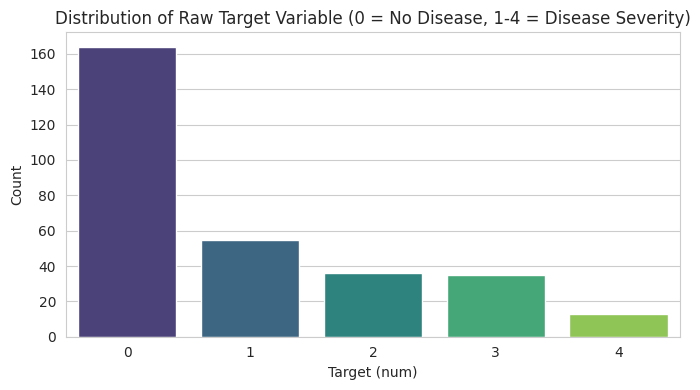

In [7]:
print("Raw target value counts:")
print(df["target"].value_counts().sort_index())

plt.figure(figsize=(7, 4))
sns.countplot(x="target", data=df, palette="viridis")
plt.title("Distribution of Raw Target Variable (0 = No Disease, 1-4 = Disease Severity)")
plt.xlabel("Target (num)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Class 0 is the largest group, but classes 1-4 combined are close in size.

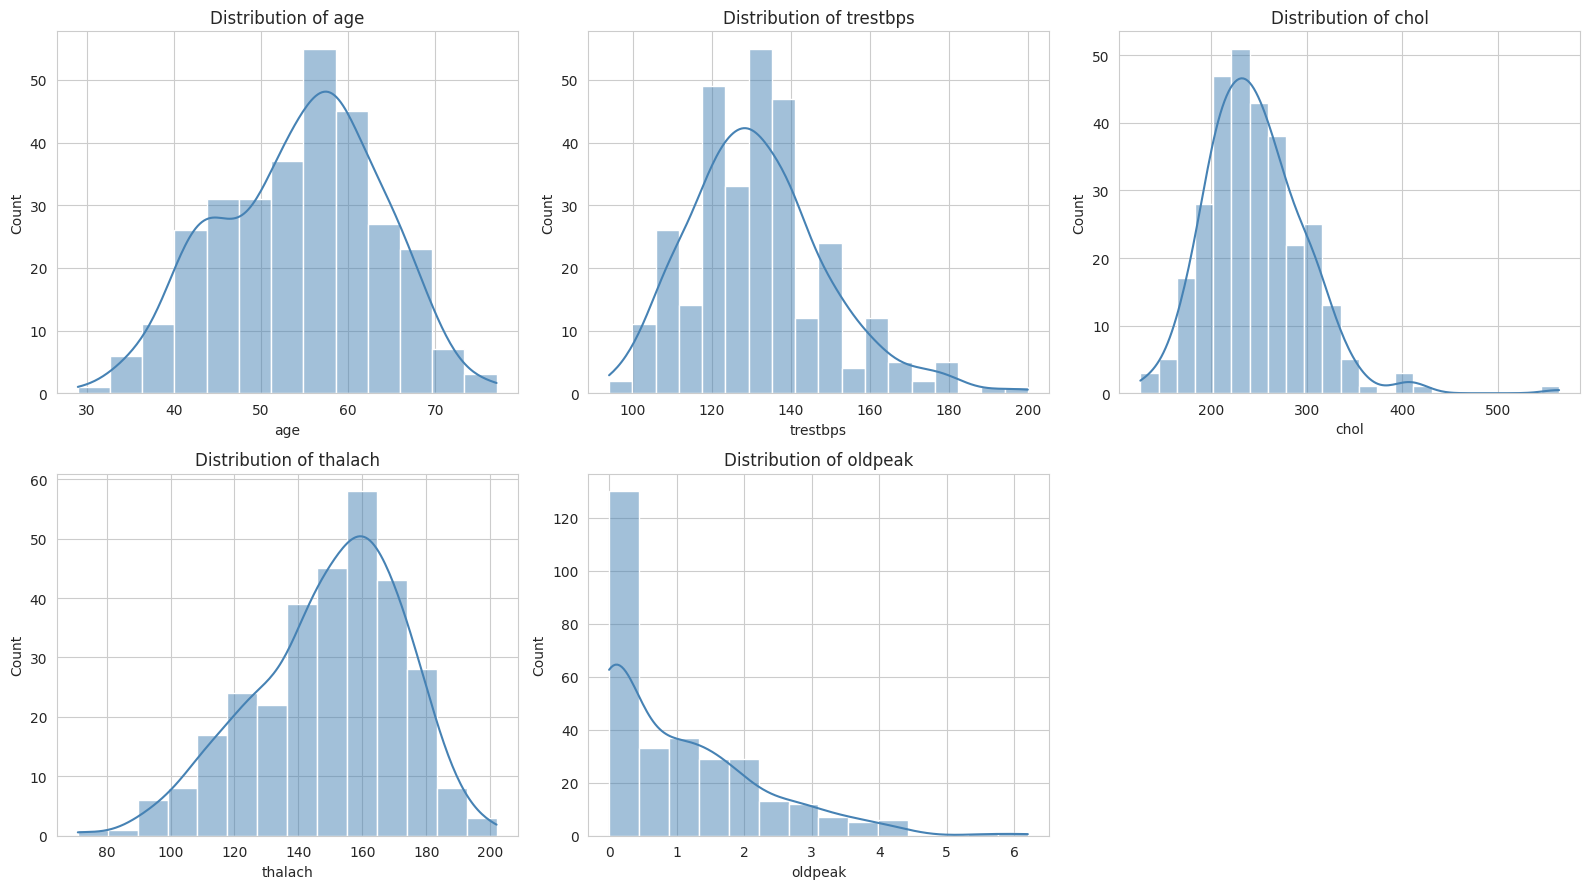

In [8]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

`chol` and `trestbps` are right-skewed.

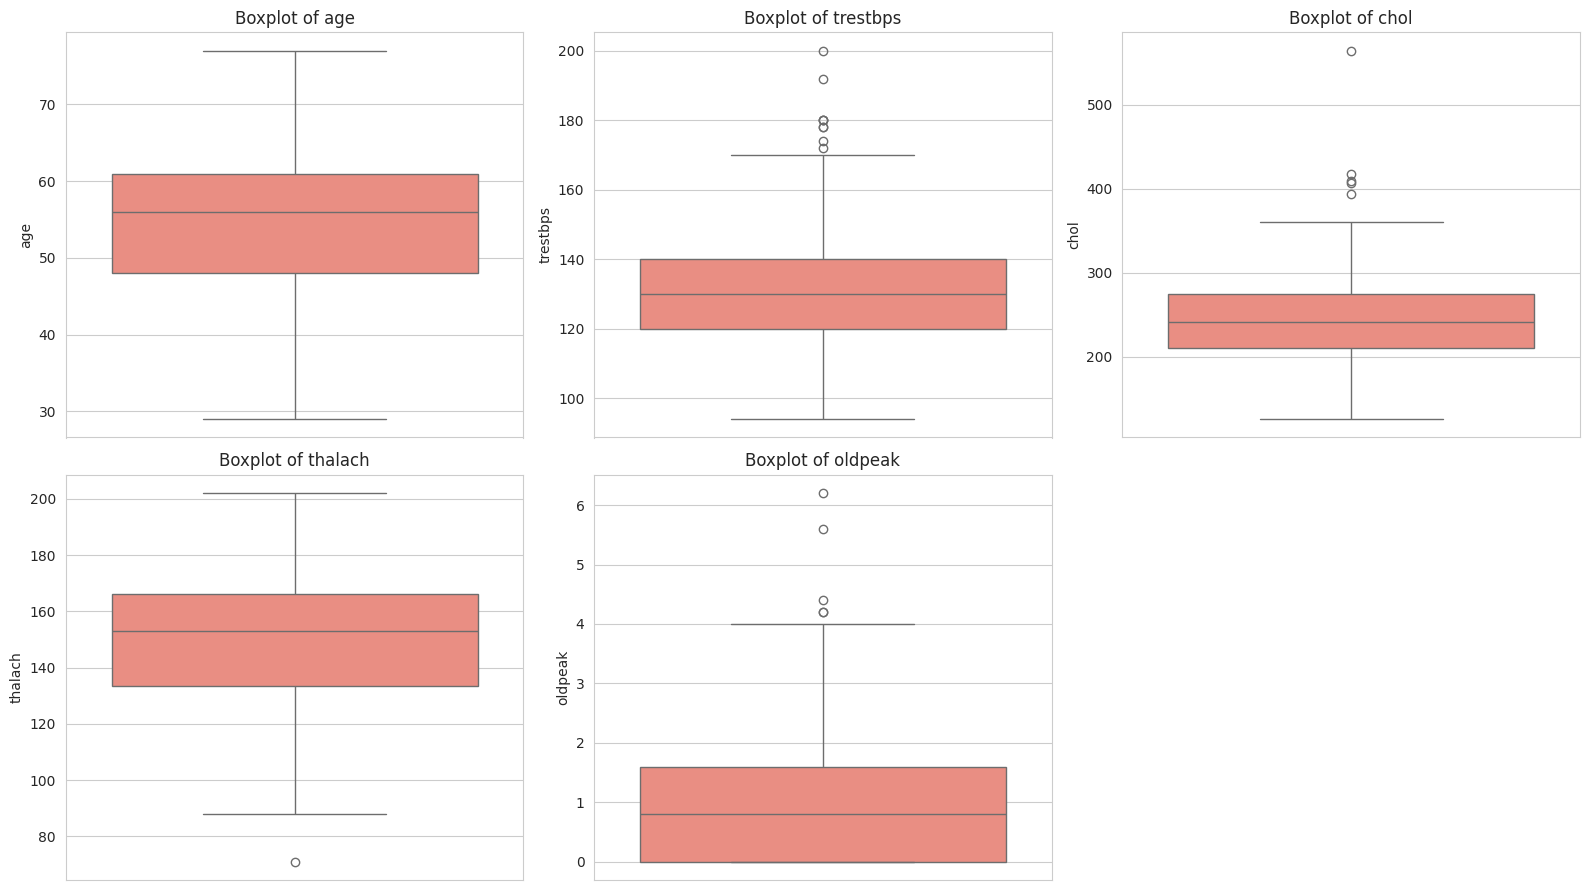

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], ax=axes[i], color="salmon")
    axes[i].set_title(f"Boxplot of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

`chol` and `trestbps` have some outliers.

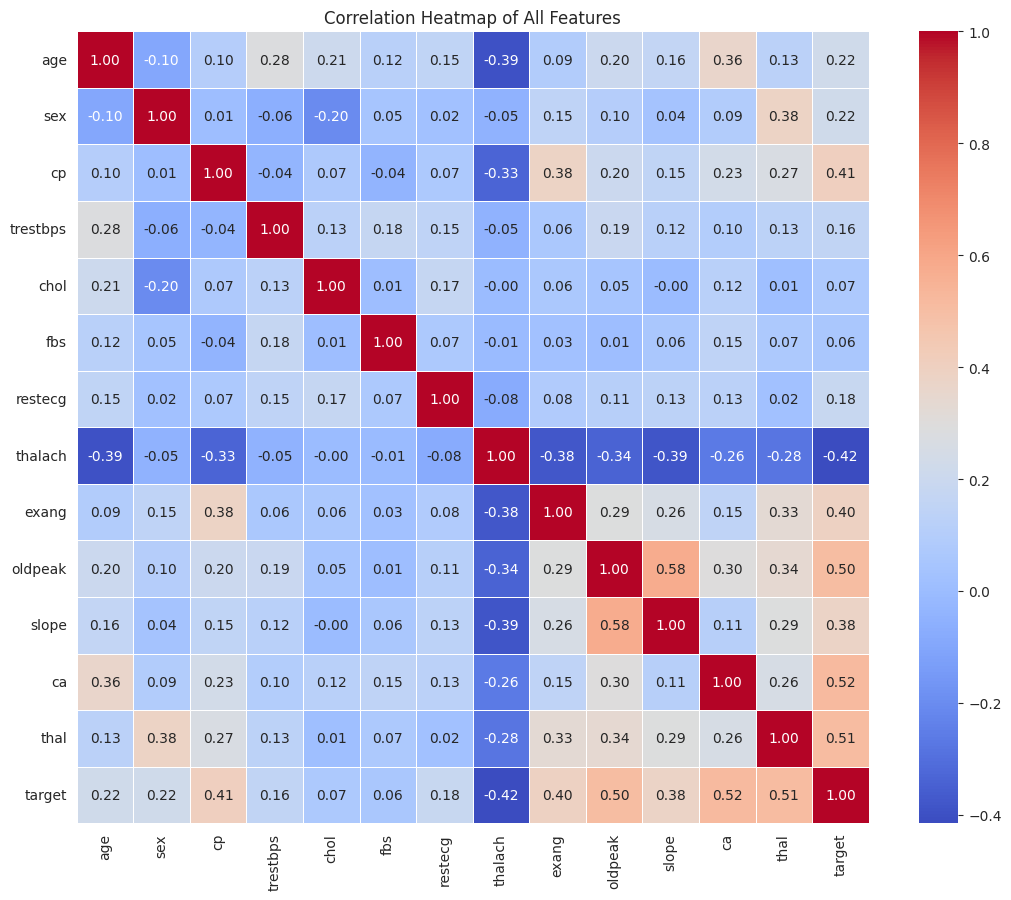

In [10]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()

No strong collinearity between features.

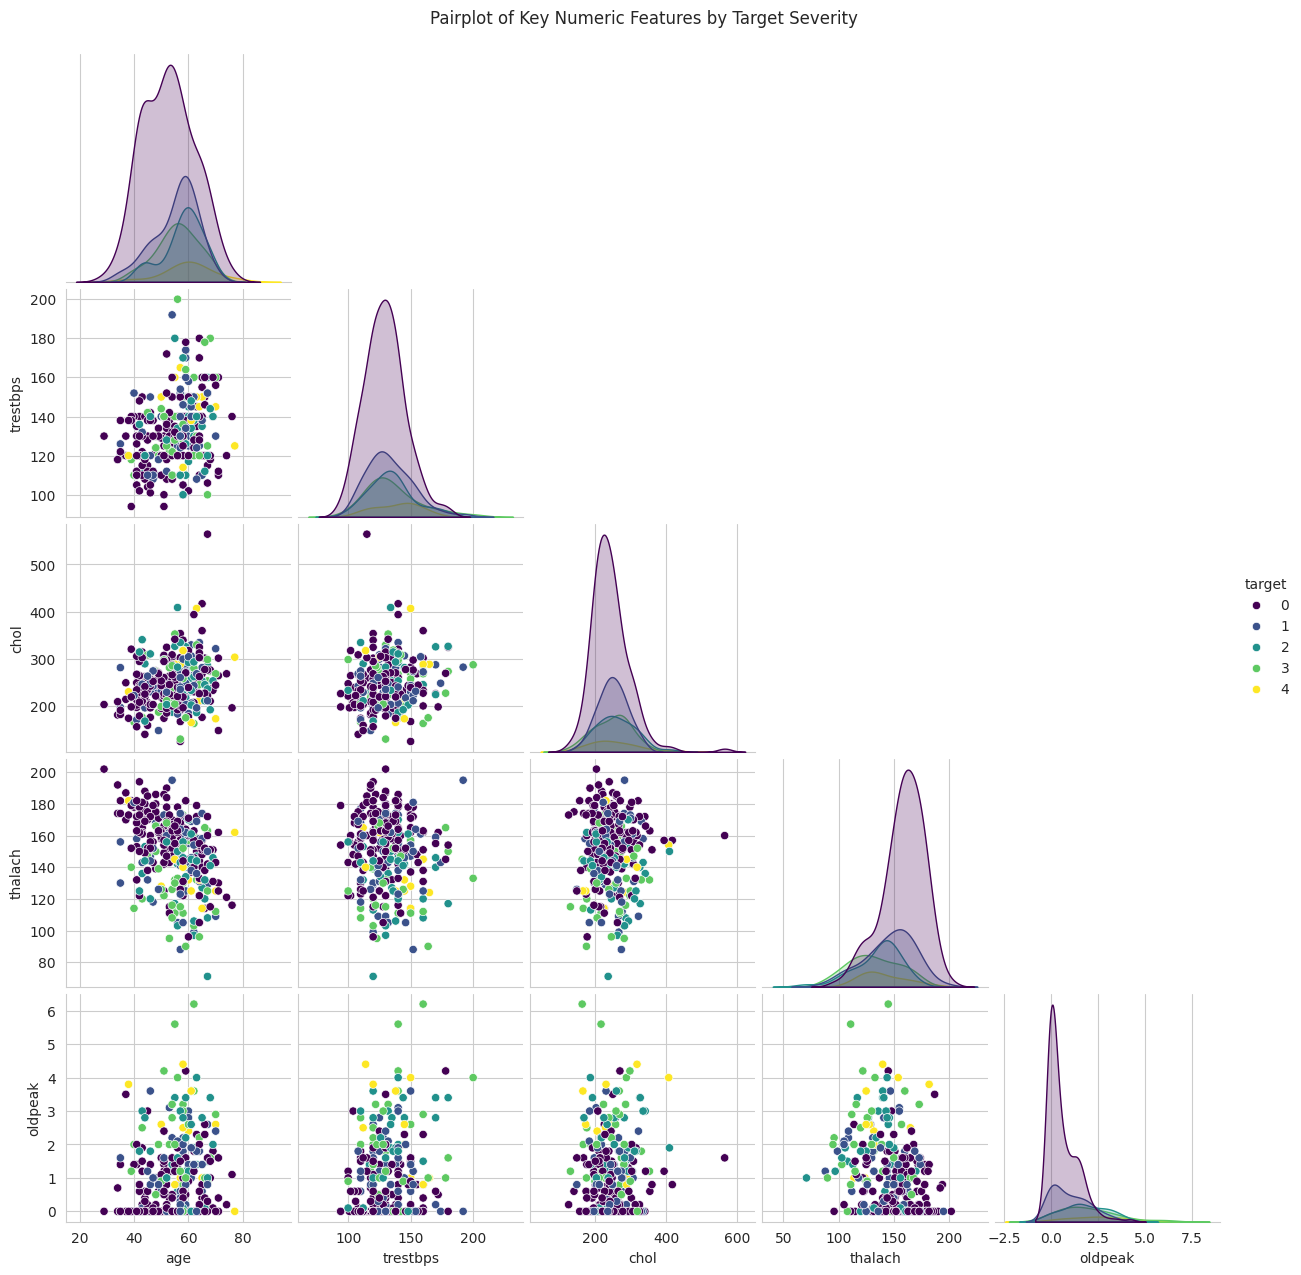

In [11]:
sns.pairplot(
    df[["age", "trestbps", "chol", "thalach", "oldpeak", "target"]].dropna(),
    hue="target", palette="viridis", diag_kind="kde", corner=True
)
plt.suptitle("Pairplot of Key Numeric Features by Target Severity", y=1.02)
plt.show()

Classes overlap across most feature pairs.

In [12]:
binary_preview = df["target"].apply(lambda x: 0 if x == 0 else 1)
print(binary_preview.value_counts())
print(f"\nProportion with disease: {binary_preview.mean():.2%}")

target
0    164
1    139
Name: count, dtype: int64

Proportion with disease: 45.87%


Roughly balanced: 54% no disease, 46% disease.

## Data Preprocessing
- Fill missing values using median.
- Convert target to binary.
- Standardize features.

In [13]:
# 1. Median imputation for columns with missing values
df_clean = df.copy()
for col in ["ca", "thal"]:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())

Remaining missing values after imputation:
0


In [14]:
# 2. Binarize the target: 0 stays 0 (no disease), 1-4 become 1 (disease present)
df_clean["target_binary"] = df_clean["target"].apply(lambda x: 0 if x == 0 else 1)

print(df_clean["target_binary"].value_counts())

target_binary
0    164
1    139
Name: count, dtype: int64


In [15]:
# 3. Feature/target split for the classification task
feature_cols = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
                 "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

X = df_clean[feature_cols]
y = df_clean["target_binary"]

X.shape, y.shape

((303, 13), (303,))

In [16]:
# 4. Train/test split (80/20), stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 242 rows
Test set: 61 rows


In [17]:
# 5. Standardize features (fit on train, apply to both train and test)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep scaled versions as DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

X_train_scaled.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,-0.729485,0.68313,0.870169,-0.395692,0.458139,-0.411196,1.022996,0.708371,-0.696177,-0.445445,0.675060,-0.689715,1.179973
208,0.050166,0.68313,-1.184278,-0.054513,0.230598,-0.411196,-0.981579,0.222495,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070
167,-0.061212,-1.46385,-1.184278,0.059213,0.723605,2.431930,1.022996,0.399178,1.436416,-0.891627,-0.958585,0.445734,-0.878070
105,-0.061212,0.68313,-1.184278,-1.305501,1.121803,-0.411196,-0.981579,0.266666,-0.696177,-0.891627,-0.958585,-0.689715,1.179973
297,0.272924,-1.46385,0.870169,0.514117,-0.167601,-0.411196,-0.981579,-1.190962,1.436416,-0.713154,0.675060,-0.689715,1.179973


## Classification Models

### Logistic Regression
Train and evaluate the model.

In [18]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


### Random Forest
Train and evaluate the model.

In [19]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest trained.")

Random Forest trained.


## Model Evaluation

In [20]:
def evaluate_classifier(name, y_true, y_pred):
    """Compute and print standard classification metrics."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1 Score": f1}

log_metrics = evaluate_classifier("Logistic Regression", y_test, y_pred_log)
rf_metrics = evaluate_classifier("Random Forest", y_test, y_pred_rf)

--- Logistic Regression ---
Accuracy:  0.8689
Precision: 0.8125
Recall:    0.9286
F1 Score:  0.8667

--- Random Forest ---
Accuracy:  0.9016
Precision: 0.8438
Recall:    0.9643
F1 Score:  0.9000



Confusion matrices.

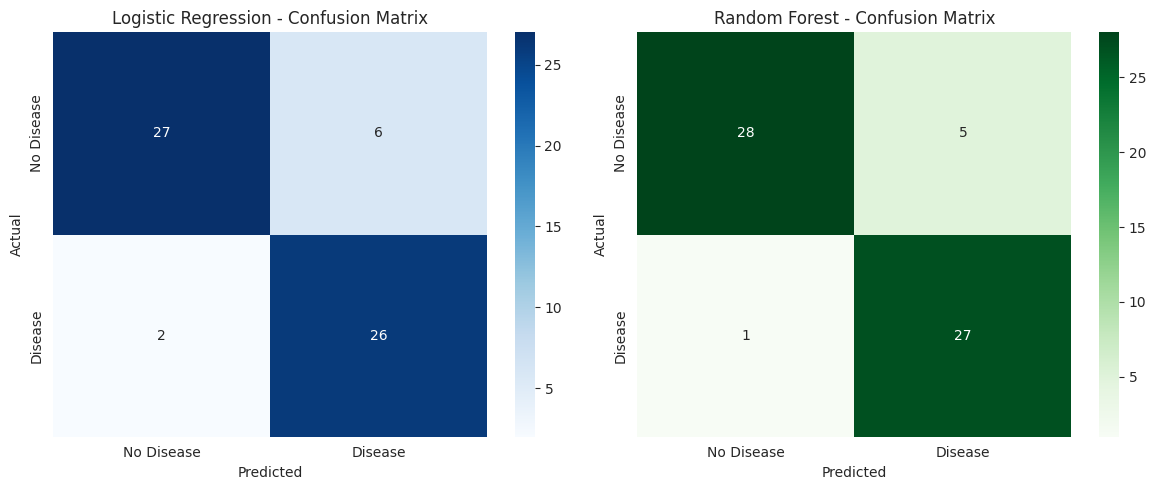

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Classification reports.

In [22]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log, target_names=["No Disease", "Disease"]))

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Disease", "Disease"]))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

Random Forest Classification Report:
              precision    recall  f1-score   support

  No Disease       0.97      0.85      0.90        33
     Disease       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



ROC curves and AUC.

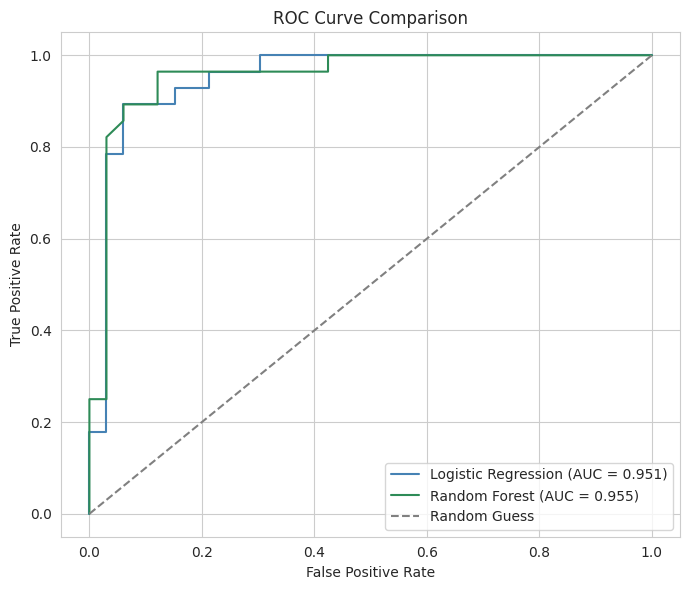

Logistic Regression ROC AUC: 0.9513
Random Forest ROC AUC:       0.9551


In [23]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})", color="steelblue")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="seagreen")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Logistic Regression ROC AUC: {auc_log:.4f}")
print(f"Random Forest ROC AUC:       {auc_rf:.4f}")

Feature importance.

/tmp/ipykernel_9559/1200632194.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


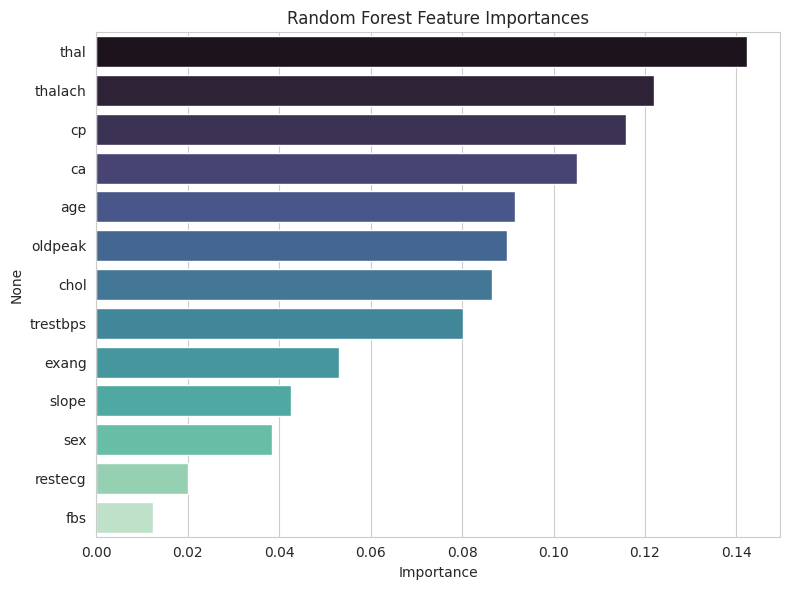

,0
thal,0.142406
thalach,0.122051
cp,0.115927
ca,0.105126
age,0.091680
oldpeak,0.089759
chol,0.086475
trestbps,0.080274
exang,0.053057
slope,0.042552


In [24]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

Comparison table.

In [25]:
log_metrics["ROC AUC"] = auc_log
rf_metrics["ROC AUC"] = auc_rf

comparison_df = pd.DataFrame([log_metrics, rf_metrics]).set_index("Model")
comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.868852,0.81250,0.928571,0.866667,0.951299
Random Forest,0.901639,0.84375,0.964286,0.900000,0.955087


Random Forest performed better than Logistic Regression based on F1-score.

In [26]:
best_model_name = comparison_df["F1 Score"].idxmax()
print(f"Based on F1 Score, the better classification model is: {best_model_name}")
print(comparison_df.loc[best_model_name])

Based on F1 Score, the better classification model is: Random Forest
Accuracy     0.901639
Precision    0.843750
Recall       0.964286
F1 Score     0.900000
ROC AUC      0.955087
Name: Random Forest, dtype: float64


## Cholesterol Prediction
Predict cholesterol using the remaining features.

In [27]:
reg_feature_cols = ["age", "sex", "cp", "trestbps", "fbs", "restecg",
                     "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

X_reg = df_clean[reg_feature_cols]
y_reg = df_clean["chol"]

# Train/test split for the regression task
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# Normalize features (fit only on training data to avoid leakage)
reg_scaler = StandardScaler()
X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train)
X_reg_test_scaled = reg_scaler.transform(X_reg_test)

print(f"Training set: {X_reg_train.shape[0]} rows, Test set: {X_reg_test.shape[0]} rows")

Training set: 242 rows, Test set: 61 rows


In [28]:
lin_reg = LinearRegression()
lin_reg.fit(X_reg_train_scaled, y_reg_train)

y_reg_pred = lin_reg.predict(X_reg_test_scaled)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")

MAE:  41.174
MSE:  3506.009
RMSE: 59.212
R2:   0.134


Actual vs predicted cholesterol.

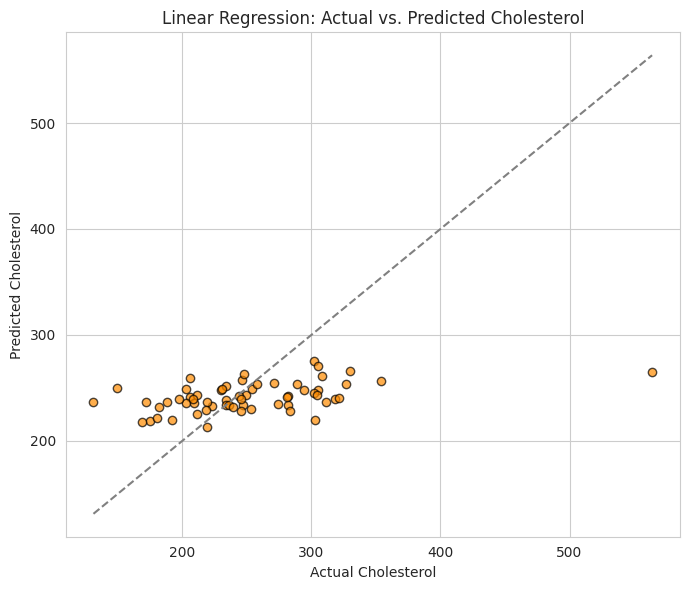

In [29]:
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.7, color="darkorange", edgecolor="k")
min_val, max_val = y_reg_test.min(), y_reg_test.max()
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="gray")
plt.xlabel("Actual Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Linear Regression: Actual vs. Predicted Cholesterol")
plt.tight_layout()
plt.show()

Correlation heatmap.

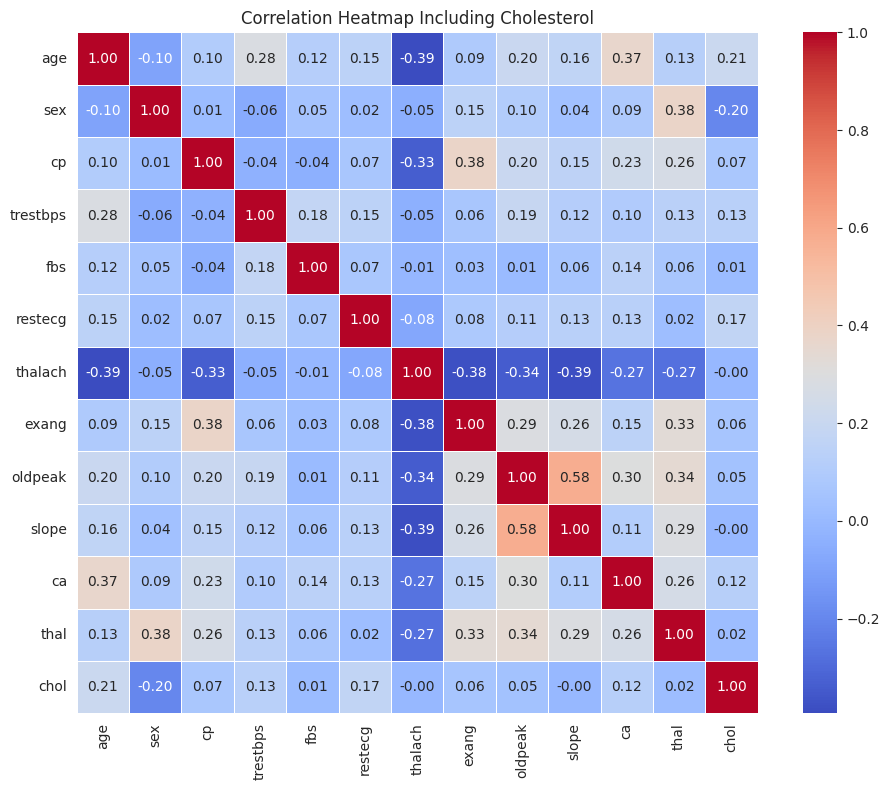

,chol
age,0.208950
sex,-0.199915
restecg,0.171043
trestbps,0.130120
ca,0.123726
cp,0.072319
exang,0.061310
oldpeak,0.046564
thal,0.018351
fbs,0.009841


In [30]:
corr_all = df_clean[reg_feature_cols + ["chol"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap Including Cholesterol")
plt.tight_layout()
plt.show()

chol_corr = corr_all["chol"].drop("chol").sort_values(key=abs, ascending=False)
chol_corr

Cholesterol has weak correlation with most features.

## PCA
Reduce dimensionality while retaining 95% variance.

In [31]:
# Standardize the full feature set (X) for PCA
pca_scaler = StandardScaler()
X_scaled_full = pca_scaler.fit_transform(X)

# Fit PCA retaining 95% of variance
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_full)

n_components = pca.n_components_
print(f"Number of principal components to retain 95% variance: {n_components}")
print(f"Reduced dataset shape: {X_pca.shape}")

Number of principal components to retain 95% variance: 12
Reduced dataset shape: (303, 12)


In [32]:
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

pca_summary = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(explained_var))],
    "Explained Variance Ratio": explained_var,
    "Cumulative Variance": cumulative_var
})
pca_summary

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.236873,0.236873
1,PC2,0.123071,0.359944
2,PC3,0.095314,0.455258
3,PC4,0.084340,0.539598
4,PC5,0.075830,0.615428
5,PC6,0.067930,0.683359
6,PC7,0.066517,0.749876
7,PC8,0.059837,0.809713
8,PC9,0.052885,0.862597
9,PC10,0.043348,0.905946


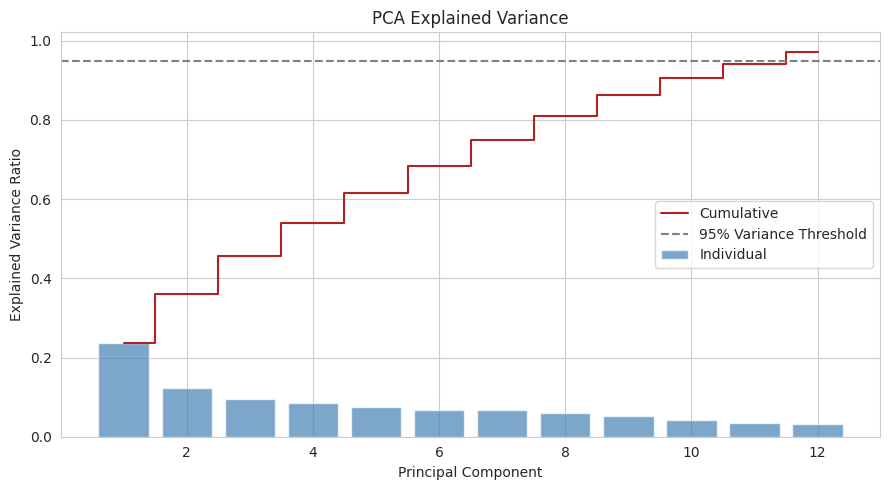

In [33]:
plt.figure(figsize=(9, 5))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, color="steelblue", label="Individual")
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where="mid", color="firebrick", label="Cumulative")
plt.axhline(y=0.95, color="gray", linestyle="--", label="95% Variance Threshold")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

PCA scatter plot.

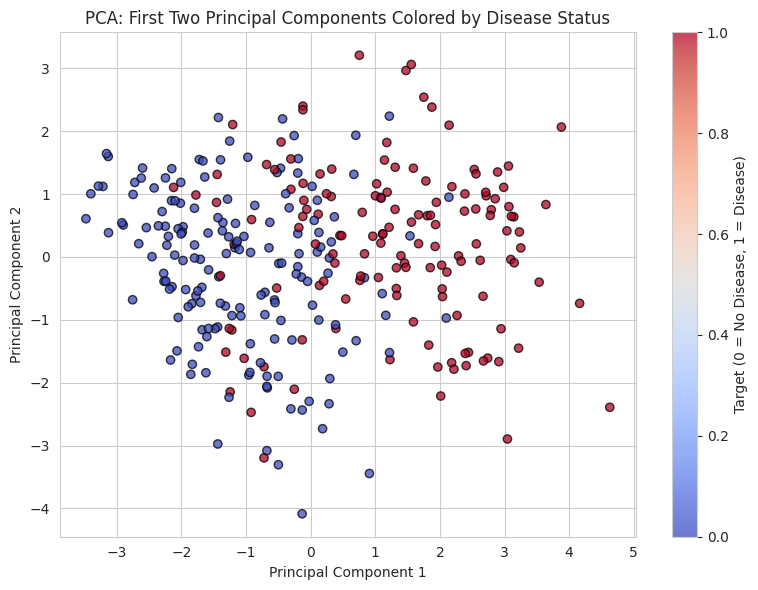

In [34]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.75, edgecolor="k")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Principal Components Colored by Disease Status")
plt.colorbar(scatter, label="Target (0 = No Disease, 1 = Disease)")
plt.tight_layout()
plt.show()

PCA retains 95% variance using 12 components.

## K-Means
Cluster the PCA-transformed data.

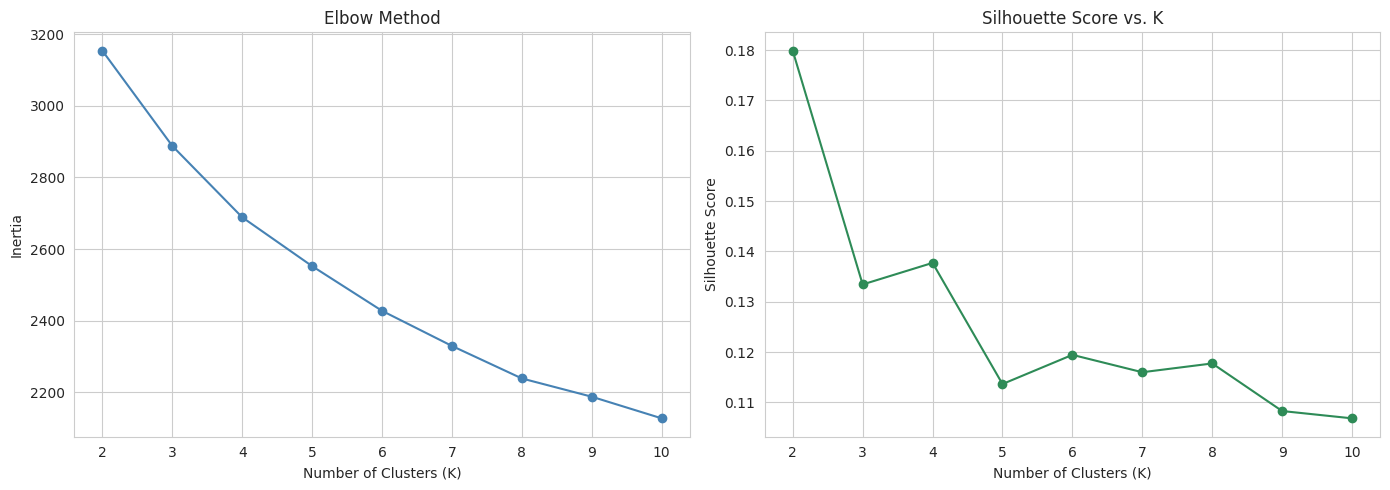

K with the highest silhouette score: 2


In [35]:
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(X_pca)
    inertia_values.append(kmeans_k.inertia_)
    silhouette_values.append(silhouette_score(X_pca, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, marker="o", color="steelblue")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="seagreen")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs. K")

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouette_values)]
print(f"K with the highest silhouette score: {best_k}")

Silhouette score suggests K=2.

In [36]:
# Train the final KMeans model using the chosen K
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_pca)

df_clean["cluster"] = cluster_labels
print(f"Final number of clusters: {best_k}")
df_clean["cluster"].value_counts().sort_index()

Final number of clusters: 2


,count
cluster,
0,114
1,189


Cluster visualization.

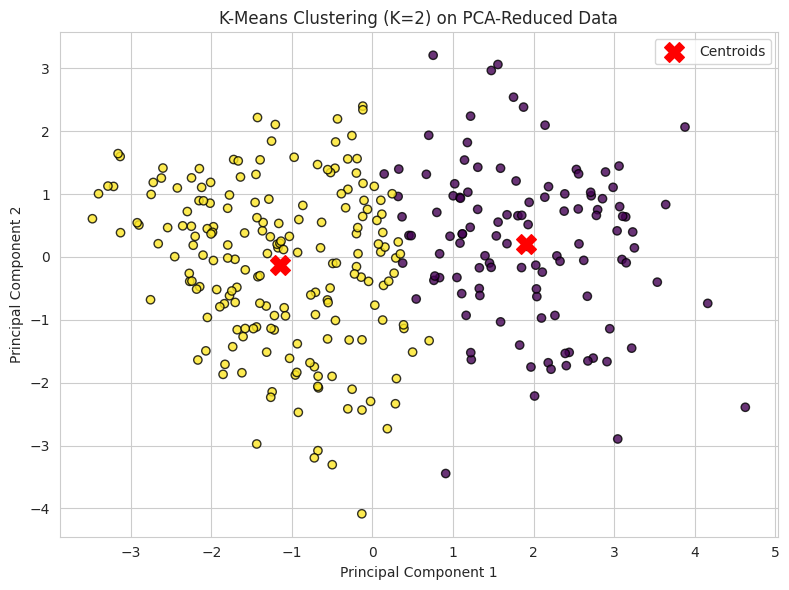

In [37]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", alpha=0.8, edgecolor="k")
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=200, label="Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"K-Means Clustering (K={best_k}) on PCA-Reduced Data")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
cluster_profile = df_clean.groupby("cluster")[feature_cols + ["target_binary"]].mean().round(2)
cluster_profile

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_binary
cluster,,,,,,,,,,,,,,
0,58.23,0.82,3.77,134.96,254.67,0.19,1.22,132.95,0.68,1.87,1.96,1.25,6.17,0.89
1,52.15,0.60,2.79,129.71,241.88,0.12,0.85,159.66,0.12,0.54,1.38,0.31,3.85,0.20


One cluster shows a higher disease rate than the other.

## Final Comparison

In [39]:
print("=== Classification: Heart Disease Prediction ===")
display(comparison_df)

print("\n=== Regression: Cholesterol Prediction ===")
regression_summary = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
    "Value": [mae, mse, rmse, r2]
})
display(regression_summary)

print("\n=== PCA Summary ===")
print(f"Original features: {X.shape[1]}")
print(f"Components retained (95% variance): {n_components}")

print("\n=== K-Means Clustering Summary ===")
print(f"Optimal number of clusters (by silhouette score): {best_k}")
print(f"Best silhouette score: {max(silhouette_values):.3f}")

=== Classification: Heart Disease Prediction ===


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.868852,0.81250,0.928571,0.866667,0.951299
Random Forest,0.901639,0.84375,0.964286,0.900000,0.955087



=== Regression: Cholesterol Prediction ===


,Metric,Value
0,MAE,41.174440
1,MSE,3506.009310
2,RMSE,59.211564
3,R2 Score,0.133676



=== PCA Summary ===
Original features: 13
Components retained (95% variance): 12

=== K-Means Clustering Summary ===
Optimal number of clusters (by silhouette score): 2
Best silhouette score: 0.180


## Conclusion
Random Forest performed best for classification. Cholesterol was hard to predict from the other features. Clustering roughly matches disease status.